In [41]:
# %pip install matplotlib
# %pip install seaborn

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
start_year = str(input("Enter start year: "))
end_year = str(input("Enter end year: "))

In [44]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet(f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet")

# View the first 5 rows
print(df.head())

            file_id  year                                          case_name  \
0  1990_1_1027_1030  1990  COLLECTOR OF CENTRAL EXCISE, CALCUTTA versus B...   
1  1990_1_1031_1040  1990  COMMISSIONER OF SALES TAX, U.P. LUCKNOW versus...   
2    1990_1_115_133  1990  STATE OF MAHARASHTRA versus CHANDRAPRAKASH KEW...   
3    1990_1_134_143  1990    P.V.G. RAJU GARU versus STATE OF ANDHRA PRADESH   
4      1990_1_13_19  1990  WORKMEN OF ENGLISH ELECTRIC COMPANY OF INDIA L...   

                                           full_text  \
0  COLLECTOR OF CENTRAL EXCISE, CALCUTTA\nv.\nBER...   
1  COMMISSIONER OF SALES TAX, U.P. LUCKNOW\nv.\nA...   
2  STAIB OF MAHARASHTRA\nv.\nCHANDRAPRAKASH KEWAL...   
3  c\nP.V.G. RAJU GARU\nv.\nSTATE OF ANDHRA PRADE...   
4  WORKMEN OF ENGLISH ELECTRIC COMPANY OF INDIA A...   

                                                acts  \
0                 [Central Excises & Salt Act, 1944]   
1                                                 []   
2             

In [45]:
numcase = 60

In [46]:
print(df.iloc[numcase].T)

file_id                                                1990_1_727_732
year                                                             1990
case_name              STATE OF KARNATAKA AND ORS. versus K.V. KHADER
full_text           ,.\nSTATE OF KARNATAKA AND ORS.\nv.\nK.V. KHAD...
acts                               [Article 14, Limitation Act, 1908]
precedents          [State of Mysore v. Kainthaje Thimmanna Enat a...
coram                                         M.H. KANIA*, R.M. SAHAI
decision_date                                              28-02-1990
case_no                                    CIVIL APPEAL No. 2763/1987
disposal_nature                                             Dismissed
neutral_citation                                           1990INSC63
Name: 60, dtype: object


In [47]:
filename = df.loc[numcase, "file_id"]
print(filename)

caseName = df.loc[numcase, 'case_name']
print(caseName)

1990_1_727_732
STATE OF KARNATAKA AND ORS. versus K.V. KHADER


In [48]:
value = df.loc[numcase, 'precedents']
print(value)

['State of Mysore v. Kainthaje Thimmanna Enat and Ors.']


In [49]:
print(f"Loaded {len(df)} records with {df.shape[1]} columns")


Loaded 26518 records with 11 columns



--- Missing Values (Top 15) ---
disposal_nature     4.16
coram               1.47
case_name           1.42
neutral_citation    1.42
case_no             1.42
decision_date       1.42
file_id             0.00
year                0.00
precedents          0.00
full_text           0.00
acts                0.00
dtype: float64


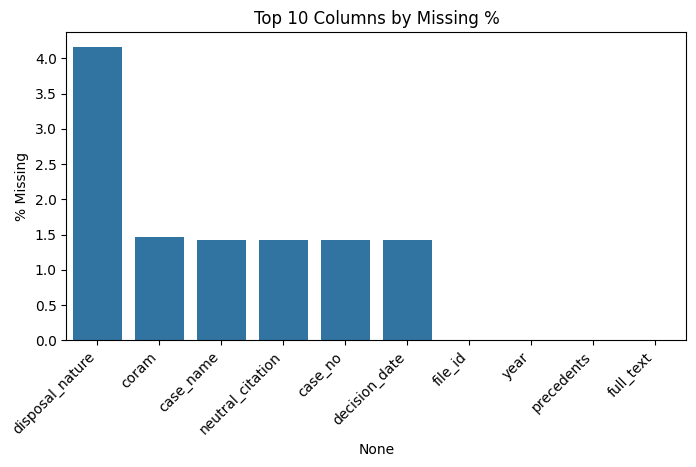

In [50]:
# Missing value audit
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Disposal Nature  Distribution ---
disposal_nature
Appeal(s) allowed                          10203
Dismissed                                   8305
Disposed off                                4178
Case Partly allowed                         1316
None                                        1104
Case Allowed                                 446
Directions issued                            270
Matter referred to larger bench              170
Leave Granted & Allowed                      148
Reference answered                            99
Hearing Adjourned                             88
Leave Granted & Dismissed                     42
Leave Granted & Disposed off                  41
Leave granted                                 24
IA disposed                                   18
Rejected                                      14
Remitted to Lower Court                       12
Dismissed After                                7
Modified                                       6
Heard         

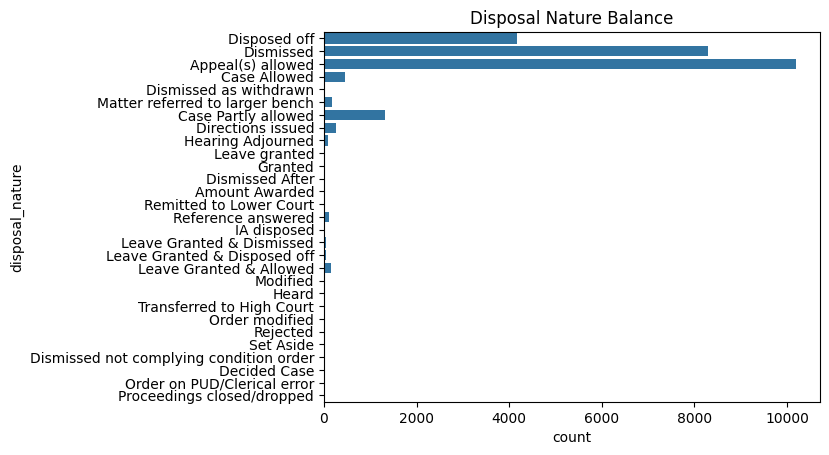

In [51]:
# Data completeness & label balance
print("\n--- Disposal Nature  Distribution ---")
print(df['disposal_nature'].value_counts(dropna=False))
sns.countplot(y='disposal_nature', data=df)
plt.title("Disposal Nature Balance")
plt.show()


--- Text Length Stats ---
count     26518.00
mean       6072.99
std        9485.65
min           7.00
25%        2409.00
50%        4079.00
75%        6813.00
max      399521.00
Name: text_len, dtype: float64


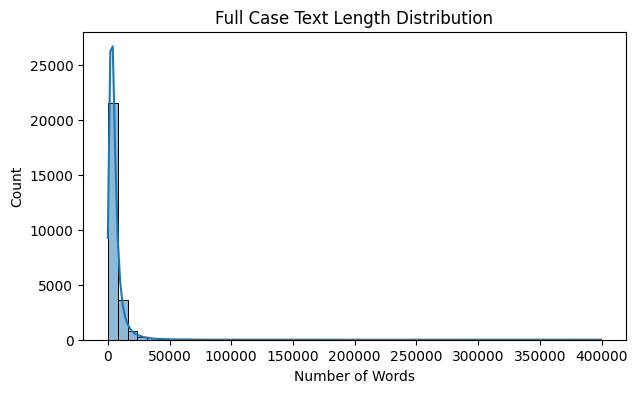

In [52]:
# =======================================
# 4️⃣ Text quality metrics
# =======================================
print("\n--- Text Length Stats ---")
df['text_len'] = df['full_text'].apply(lambda x: len(str(x).split()))
print(df['text_len'].describe().round(2))

plt.figure(figsize=(7,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Full Case Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()


--- Top 10 Acts/Articles Distribution ---
acts
Article 226                   2785
Article 14                    2274
Article 136                   2132
Article 32                    2111
Article 21                    1228
Evidence Act, 1872            1165
Land Acquisition Act, 1894    1083
Article 142                    917
Income Tax Act, 1961           803
Article 19                     791
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3924\888404709.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')


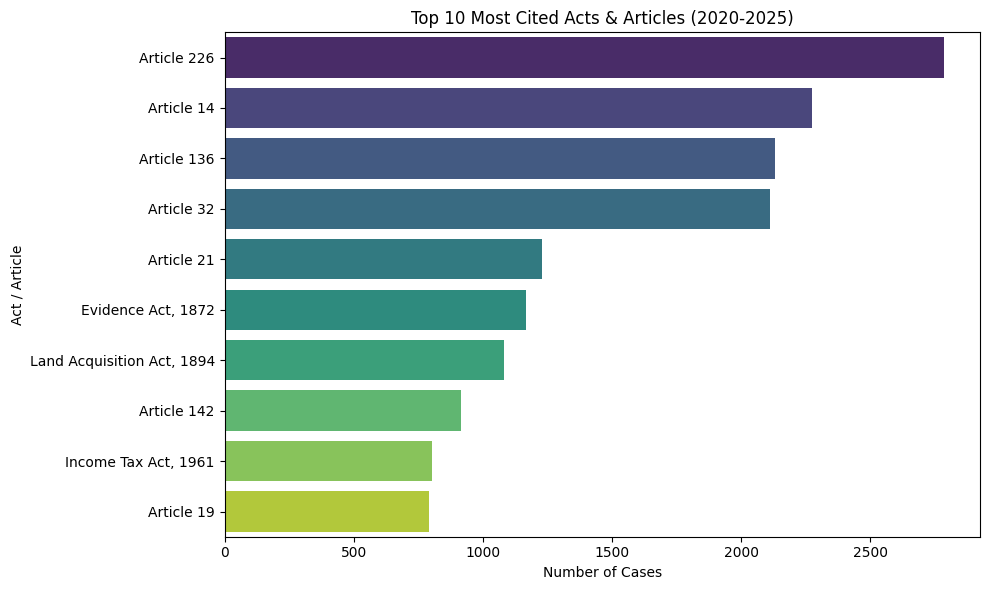

In [53]:
# 1. Explode the 'acts' column so each Act gets its own row
df_exploded = df.explode('acts')

# 2. Drop rows where 'acts' might be None (cases with no identified laws)
df_exploded = df_exploded.dropna(subset=['acts'])

# 3. Calculate the Top 10 Acts for a readable plot
top_10_acts = df_exploded['acts'].value_counts().nlargest(10)

print("\n--- Top 10 Acts/Articles Distribution ---")
print(top_10_acts)

# 4. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')

plt.title("Top 10 Most Cited Acts & Articles (2020-2025)")
plt.xlabel("Number of Cases")
plt.ylabel("Act / Article")
plt.tight_layout()
plt.show()

In [54]:
# Identify cases where metadata extraction failed
failed_cases = df[df['case_name'].isnull()][['file_id', 'year']].head(10)

print("--- Samples of Files with Missing Metadata ---")
print(failed_cases)

--- Samples of Files with Missing Metadata ---
              file_id  year
6276    2008_10_48_51  2008
6278     2008_10_4_47  2008
6279    2008_10_52_61  2008
6288    2008_10_62_70  2008
6316  2008_10_905_915  2008
6340  2008_11_145_160  2008
6342  2008_11_172_183  2008
6343  2008_11_184_210  2008
6346  2008_11_211_242  2008
6347  2008_11_243_269  2008
